In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from queue import Queue

Initial total obstacles: 13

Epoch 1:
Current maze solvable: True
Episode terminated early due to max_steps (500) reached.
Episode terminated early due to max_steps (500) reached.
Episode terminated early due to max_steps (500) reached.
Avg Reward: -659.6, Success Rate: 40.0% (2/5)
Using best path (reward -6, solved: True) for adversary.


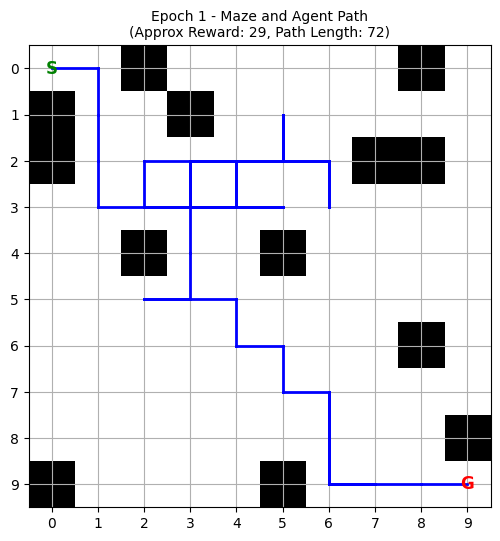

Environment updated: Added 1 obstacle(s) near path (total obstacles now: 14).

Epoch 2:
Current maze solvable: True
Episode terminated early due to max_steps (500) reached.
Avg Reward: -526.0, Success Rate: 80.0% (4/5)
Using best path (reward -330, solved: True) for adversary.


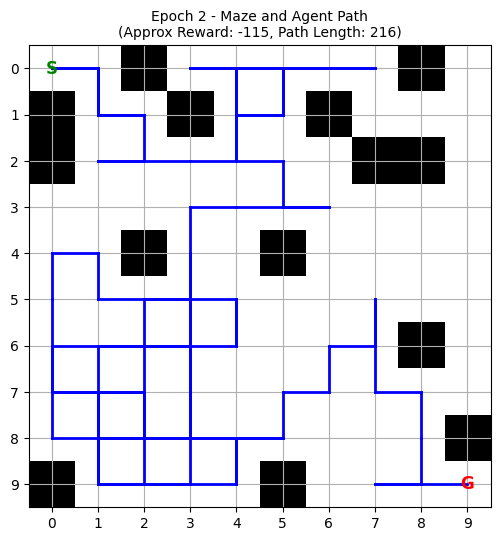

Environment updated: Added 1 obstacle(s) near path (total obstacles now: 15).

Epoch 3:
Current maze solvable: True
Avg Reward: -210.8, Success Rate: 100.0% (5/5)
Using best path (reward -88, solved: True) for adversary.


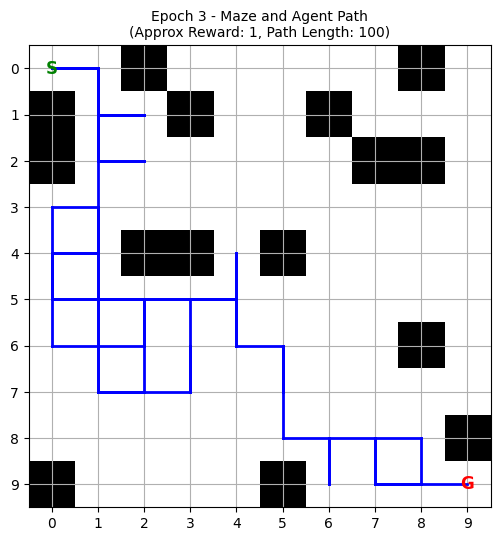

Environment updated: Added 1 obstacle(s) near path (total obstacles now: 16).

Epoch 4:
Current maze solvable: True
Avg Reward: -92.0, Success Rate: 100.0% (5/5)
Using best path (reward 33, solved: True) for adversary.


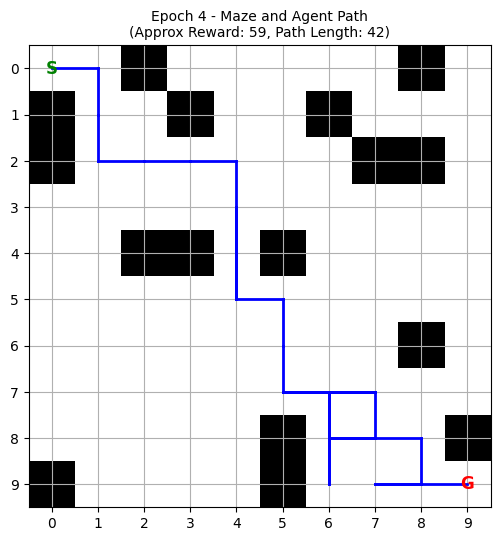

Environment updated: Added 1 obstacle(s) near path (total obstacles now: 17).

Epoch 5:
Current maze solvable: True
Avg Reward: -139.6, Success Rate: 100.0% (5/5)
Using best path (reward -39, solved: True) for adversary.


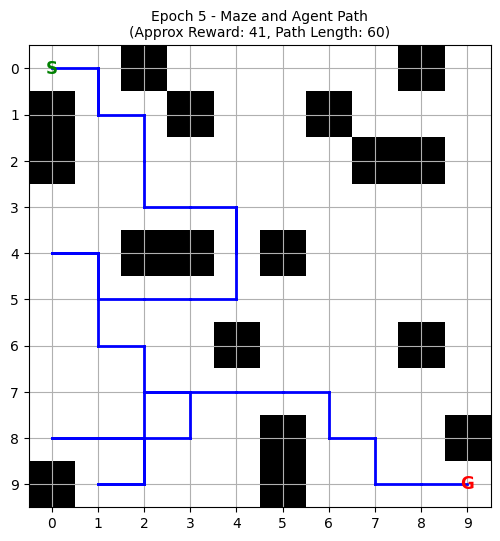

Environment updated: Added 1 obstacle(s) near path (total obstacles now: 18).

Epoch 6:
Current maze solvable: True
Avg Reward: -42.4, Success Rate: 100.0% (5/5)
Using best path (reward -4, solved: True) for adversary.


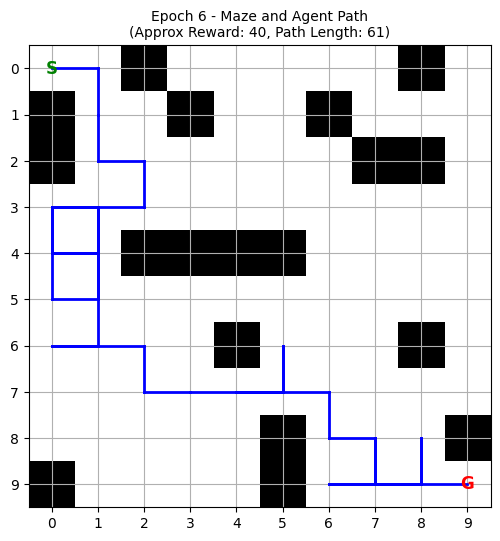

Proposed 1 obstacles made maze unsolvable.
Even 1 obstacle blocks path.

Epoch 7:
Current maze solvable: True
Avg Reward: -3.2, Success Rate: 100.0% (5/5)
Using best path (reward 51, solved: True) for adversary.


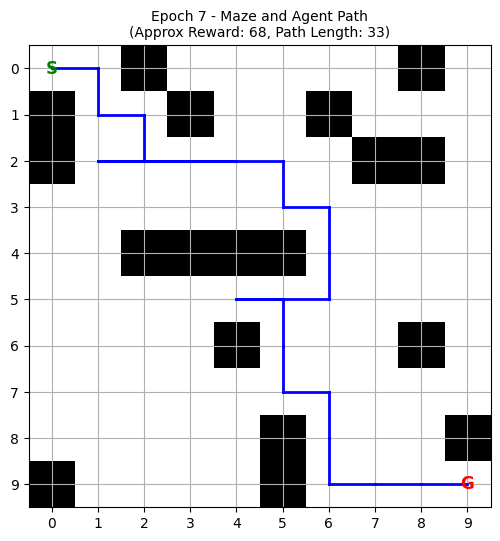

Environment updated: Added 1 obstacle(s) near path (total obstacles now: 19).

Epoch 8:
Current maze solvable: True
Avg Reward: 9.8, Success Rate: 100.0% (5/5)
Using best path (reward 28, solved: True) for adversary.


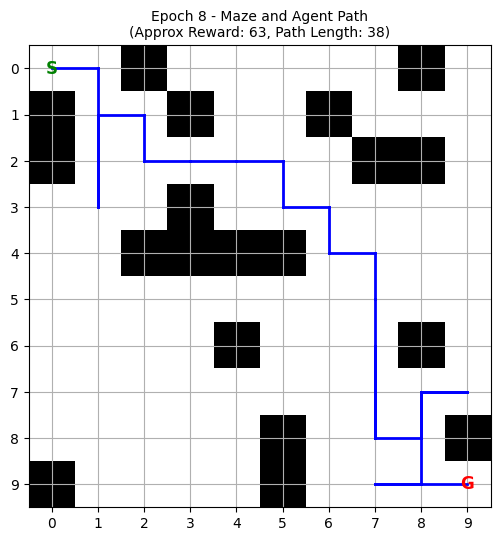

Environment updated: Added 1 obstacle(s) near path (total obstacles now: 20).

Epoch 9:
Current maze solvable: True
Avg Reward: -59.4, Success Rate: 100.0% (5/5)
Using best path (reward 4, solved: True) for adversary.


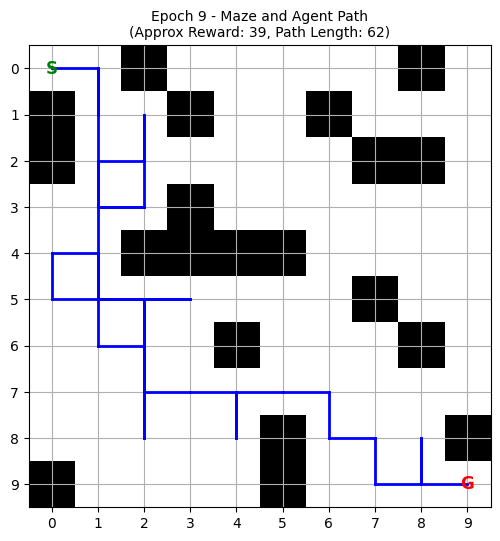

Environment updated: Added 1 obstacle(s) near path (total obstacles now: 21).

Epoch 10:
Current maze solvable: True
Avg Reward: 24.6, Success Rate: 100.0% (5/5)
Using best path (reward 50, solved: True) for adversary.


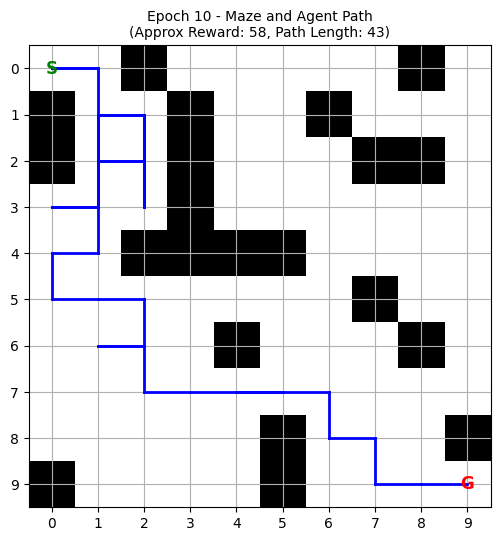

Environment updated: Added 1 obstacle(s) near path (total obstacles now: 22).

Training complete! Final total obstacles: 22


In [ ]:
class MazeEnv:
    def __init__(self, size=5, obstacle_prob=0.2):
        self.size = size
        self.grid = np.zeros((size, size), dtype=int)
        self.start = (0, 0)
        self.goal = (size-1, size-1)
        self.generate_maze(obstacle_prob)
        self.agent_pos = self.start
        self.done = False

    def generate_maze(self, obstacle_prob):
        # randomly place obstacles
        for i in range(self.size):
            for j in range(self.size):
                if (i, j) != self.start and (i, j) != self.goal:
                    if random.random() < obstacle_prob:
                        self.grid[i, j] = 1

    def reset(self):
        self.agent_pos = self.start
        self.done = False
        return self.agent_pos

    def step(self, action):
        # Actions: 0=up, 1=down, 2=left, 3=right
        i, j = self.agent_pos
        if action == 0 and i > 0: i -= 1
        elif action == 1 and i < self.size-1: i += 1
        elif action == 2 and j > 0: j -= 1
        elif action == 3 and j < self.size-1: j += 1

        new_pos = (i, j)
        reward = -1
        if self.grid[i, j] == 1:
            reward = -10
            new_pos = self.agent_pos
        elif new_pos == self.goal:
            reward = 100
            self.done = True

        self.agent_pos = new_pos
        return new_pos, reward, self.done

    def get_state_space(self):
        return self.size * self.size

    def is_solvable(self):
        visited = np.zeros((self.size, self.size), dtype=bool)
        queue = Queue()
        queue.put(self.start)
        visited[self.start[0], self.start[1]] = True

        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # up, down, left, right

        while not queue.empty():
            i, j = queue.get()
            if (i, j) == self.goal:
                return True
            for di, dj in directions:
                ni, nj = i + di, j + dj
                if 0 <= ni < self.size and 0 <= nj < self.size and not visited[ni, nj] and self.grid[ni, nj] == 0:
                    visited[ni, nj] = True
                    queue.put((ni, nj))
        return False

# Q-Learning Agent
class QLearningAgent:
    def __init__(self, env, alpha=0.2, gamma=0.99, epsilon=0.8, epsilon_decay=0.99):
        self.env = env
        self.q_table = defaultdict(lambda: np.zeros(4))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay

    def state_to_key(self, state):
        return state[0] * self.env.size + state[1]

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, 3)
        return np.argmax(self.q_table[self.state_to_key(state)])

    def update(self, state, action, reward, next_state):
        key = self.state_to_key(state)
        next_key = self.state_to_key(next_state)
        best_next = np.max(self.q_table[next_key])
        self.q_table[key][action] += self.alpha * (reward + self.gamma * best_next - self.q_table[key][action])

    def train_episode(self, max_steps=500):
        state = self.env.reset()
        total_reward = 0
        path = [state]
        steps = 0
        while not self.env.done and steps < max_steps:
            action = self.choose_action(state)
            next_state, reward, done = self.env.step(action)
            self.update(state, action, reward, next_state)
            state = next_state
            total_reward += reward
            path.append(state)
            steps += 1
            if done:
                break
        if steps >= max_steps and not self.env.done:
            print(f"Episode terminated early due to max_steps ({max_steps}) reached.")
        self.epsilon *= self.epsilon_decay
        return total_reward, path, self.env.done

# Secondary Agent
class AdversaryAgent:
    def __init__(self, env_size, num_to_add=2):
        self.size = env_size
        self.num_to_add = num_to_add

    def adapt_environment(self, env, primary_path):
        new_grid = env.grid.copy()

        free_cells = []
        for i in range(self.size):
            for j in range(self.size):
                if env.grid[i, j] == 0 and (i, j) != env.start and (i, j) != env.goal:
                    dist_to_path = min(np.sqrt((i - p[0])**2 + (j - p[1])**2) for p in primary_path)
                    free_cells.append(((i, j), dist_to_path))

        if not free_cells:
            print("No free cells left to add obstacles. Maze unchanged.")
            return

        free_cells.sort(key=lambda x: x[1])
        candidates = free_cells[:len(free_cells) // 2]
        random.shuffle(candidates)
        to_add = [pos for pos, _ in candidates[:self.num_to_add]]

        for pos in to_add:
            new_grid[pos] = 1

        temp_env = MazeEnv(size=self.size)
        temp_env.grid = new_grid
        if not temp_env.is_solvable():
            print(f"Proposed {len(to_add)} obstacles made maze unsolvable.")
            if self.num_to_add > 1:
                self.num_to_add -= 1
                return self.adapt_environment(env, primary_path)
            else:
                print("Even 1 obstacle blocks path.")
                return

        num_added = len(to_add)
        env.grid = new_grid
        print(f"Environment updated: Added {num_added} obstacle(s) near path (total obstacles now: {np.sum(env.grid)}).")

# Visualization Function
def visualize_maze(env, path, epoch):
    plt.figure(figsize=(6, 6))
    plt.imshow(env.grid, cmap='gray_r', origin='upper')
    plt.text(env.start[1], env.start[0], 'S', ha='center', va='center', color='green', fontsize=12, weight='bold')
    plt.text(env.goal[1], env.goal[0], 'G', ha='center', va='center', color='red', fontsize=12, weight='bold')

    # Plot path
    for i in range(len(path) - 1):
        y1, x1 = path[i]
        y2, x2 = path[i+1]
        plt.plot([x1, x2], [y1, y2], color='blue', linewidth=2)

    approx_reward = -1 * (len(path) - 1) + 100 if path[-1] == env.goal else -len(path)
    plt.title(f'Epoch {epoch} - Maze and Agent Path\n(Approx Reward: {approx_reward}, Path Length: {len(path)})', fontsize=10)
    plt.xticks(range(env.size))
    plt.yticks(range(env.size))
    plt.grid(True)
    plt.show(block=False)
    plt.pause(2)
    plt.close()

def main(num_epochs=5, maze_size=10, num_episodes_per_epoch=5):
    env = MazeEnv(size=maze_size, obstacle_prob=0.1)
    primary_agent = QLearningAgent(env)
    adversary = AdversaryAgent(maze_size, num_to_add=1)

    print(f"Initial total obstacles: {np.sum(env.grid)}")

    for epoch in range(1, num_epochs + 1):
        print(f'\nEpoch {epoch}:')
        print(f"Current maze solvable: {env.is_solvable()}")

        episodes = []
        for ep in range(num_episodes_per_epoch):
            reward, path, solved = primary_agent.train_episode()
            episodes.append((reward, path, solved))

        avg_reward = np.mean([r for r, p, s in episodes])
        success_rate = np.mean([s for r, p, s in episodes]) * 100
        print(f'Avg Reward: {avg_reward:.1f}, Success Rate: {success_rate:.1f}% ({sum(s for _,_,s in episodes)}/{num_episodes_per_epoch})')

        best_idx = np.argmax([r for r, _, _ in episodes])
        best_reward, best_path, best_solved = episodes[best_idx]

        if any(s for _, _, s in episodes):
            if not best_solved:
                for r, p, s in episodes:
                    if s:
                        best_path = p
                        break
            print(f'Using best path (reward {best_reward}, solved: {best_solved}) for adversary.')
            visualize_maze(env, best_path, epoch)
            adversary.adapt_environment(env, best_path)
        else:
            print("No successes this epoch.")
            visualize_maze(env, best_path, epoch)

    print("\nTraining complete! Final total obstacles:", np.sum(env.grid))

if __name__ == '__main__':
    random.seed(42)
    main(num_epochs=10)